In [12]:
import sys
sys.path.append('../../../../src')
import pickle
from energiapy.plot import plot_results, plot_scenario, plot_location
from matplotlib import pyplot as plt
from matplotlib import rc
import numpy as np
from typing import Any, Dict, Tuple, List
from itertools import groupby
import textwrap
from numpy.polynomial.hermite import hermgauss
from scipy.stats import norm

In [13]:
def compute_ttr(backlog: Dict[Tuple[Any, ...], float], *, zero_tol: float = 1e-9, return_open: bool = True) -> Dict[Tuple[Any, Any], List[Dict[str, Any]]]:
    if not backlog:
        return {}

    # Prepare (group, time_tuple, value) triples and sort by (group, time)
    triples = []
    for k, v in backlog.items():
        if len(k) < 3:
            raise ValueError(f"Key {k} must have at least (loc, com, time...).")
        triples.append(((k[0], k[1]), k[2:], float(v)))
    triples.sort(key=lambda x: (x[0], x[1]))  # lexicographic time handles multi-index

    results: Dict[Tuple[Any, Any], List[Dict[str, Any]]] = {}

    for g, grp in groupby(triples, key=lambda x: x[0]):
        episodes: List[Dict[str, Any]] = []
        in_run = False
        start = None
        peak = area = 0.0
        steps = 0

        for _, t, val in grp:
            if val > zero_tol:
                if not in_run:
                    in_run = True
                    start = t
                    peak = val
                    area = val
                    steps = 1
                else:
                    steps += 1
                    area += val
                    if val > peak:
                        peak = val
            elif in_run:
                episodes.append({
                    "start_idx": start,
                    "end_idx": t,                 # first nonpositive period
                    "duration_steps": steps,
                    "peak": peak,
                    "area": area,
                })
                in_run = False

        if in_run and return_open:
            episodes.append({
                "start_idx": start,
                "end_idx": None,                  # not yet recovered
                "duration_steps": steps,
                "peak": peak,
                "area": area,
            })
        
        if episodes !=[]:
            results[g] = episodes
        else:
            continue

    return results

In [14]:
dark_colors = [
    "black",
    "dimgray",
    "gray",
    "dimgrey",
    "slategrey",
    "darkslategray",
    "darkslategrey",
    "darkgray",
    "darkblue",
    "midnightblue",
    "navy",
    "darkgreen",
    "forestgreen",
    "darkolivegreen",
    "darkred",
    "firebrick",
    "maroon",
    "darkmagenta",
    "indigo",
    "darkviolet",
    "purple",
    "darkorange",
    "saddlebrown",
    "chocolate",
    "darkgoldenrod"
]

In [38]:
with open(f'control/ncl_ControlResults_Backlog_ph30.pkl', 'rb') as file:
    ncl_load_results = pickle.load(file)

In [39]:
with open(f'control/cl_ControlResults_Backlog_ph30.pkl', 'rb') as file:
    cl_load_results = pickle.load(file)

In [17]:
with open(f'control/cl_step2_ControlResults_Backlog.pkl', 'rb') as file:
    cl_step2_load_results = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'control/cl_step2_ControlResults_Backlog.pkl'

In [18]:
with open(f'control/cl_step2_ControlResults_Backlog_ncl_des.pkl', 'rb') as file:
    cl_step2_ncl_des_load_results = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'control/cl_step2_ControlResults_Backlog_ncl_des.pkl'

In [19]:
with open(f'control/cl_step3_ControlResults_Backlog.pkl', 'rb') as file:
    cl_step3_load_results = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'control/cl_step3_ControlResults_Backlog.pkl'

In [20]:
with open(f'control/cl_step3_ControlResults_Backlog_ncl_des.pkl', 'rb') as file:
    cl_step3_ncl_des_load_results = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'control/cl_step3_ControlResults_Backlog_ncl_des.pkl'

In [21]:
with open(f'control/cl_step4_ControlResults_Backlog.pkl', 'rb') as file:
    cl_step4_load_results = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'control/cl_step4_ControlResults_Backlog.pkl'

In [22]:
with open(f'control/cl_step3_ControlResults_Backlog_sd_ncl_des.pkl', 'rb') as file:
    cl_step3_sd_ncl_des_load_results = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'control/cl_step3_ControlResults_Backlog_sd_ncl_des.pkl'

In [27]:
with open(f'control/cl_step2_ControlResults_Backlog_res1.pkl', 'rb') as file:
    cl_step2_res1_load_results = pickle.load(file)

In [28]:
with open(f'control/cl_step2_ControlResults_Backlog_res1_ncl_des.pkl', 'rb') as file:
    cl_step2_res1_ncl_des_load_results = pickle.load(file)

In [29]:
ttr = compute_ttr(backlog=cl_step2_res1_ncl_des_load_results.output['Demand_backlog'])

In [30]:
ttr

{('loc5',
  'com1_sold'): [{'start_idx': (0, 0, 1),
   'end_idx': (0, 1, 3),
   'duration_steps': 9,
   'peak': 650.0,
   'area': 3495.0}, {'start_idx': (0, 28, 6),
   'end_idx': (0, 42, 0),
   'duration_steps': 92,
   'peak': 4650.0,
   'area': 220860.0}]}

In [31]:
ncl_load_results.output['Cap_P']

NameError: name 'ncl_load_results' is not defined

In [32]:
cl_step2_load_results.output['Cap_S']

NameError: name 'cl_step2_load_results' is not defined

In [33]:
cl_step3_load_results.output['Cap_S']

NameError: name 'cl_step3_load_results' is not defined

In [34]:
# with open(f'control/ncl_ControlResults_Backlog_ph30.pkl', 'rb') as file:
#     ph30_ncl_load_results = pickle.load(file)

In [35]:
# with open(f'control/cl_ControlResults_Backlog_ph30.pkl', 'rb') as file:
#     ph30_cl_load_results = pickle.load(file)

In [17]:
print(*[(k,v) for k,v in cl_step3_sd_ncl_des_load_results.output['P'].items() if k[0]=='loc2' and k[1]=='com1_process' and v], sep='\n')

(('loc2', 'com1_process', 0, 0, 3), 445.0)
(('loc2', 'com1_process', 0, 0, 4), 445.0)
(('loc2', 'com1_process', 0, 0, 5), 100.0)
(('loc2', 'com1_process', 0, 0, 6), 100.0)
(('loc2', 'com1_process', 0, 1, 0), 100.0)
(('loc2', 'com1_process', 0, 1, 1), 100.0)
(('loc2', 'com1_process', 0, 1, 2), 100.0)
(('loc2', 'com1_process', 0, 1, 3), 100.0)
(('loc2', 'com1_process', 0, 1, 4), 100.0)
(('loc2', 'com1_process', 0, 1, 5), 100.0)
(('loc2', 'com1_process', 0, 1, 6), 100.0)
(('loc2', 'com1_process', 0, 2, 0), 100.0)
(('loc2', 'com1_process', 0, 2, 1), 100.0)
(('loc2', 'com1_process', 0, 2, 2), 100.0)
(('loc2', 'com1_process', 0, 2, 3), 100.0)
(('loc2', 'com1_process', 0, 2, 4), 100.0)
(('loc2', 'com1_process', 0, 2, 5), 100.0)
(('loc2', 'com1_process', 0, 2, 6), 100.0)
(('loc2', 'com1_process', 0, 3, 0), 100.0)
(('loc2', 'com1_process', 0, 3, 1), 100.0)
(('loc2', 'com1_process', 0, 3, 2), 100.0)
(('loc2', 'com1_process', 0, 3, 3), 100.0)
(('loc2', 'com1_process', 0, 3, 4), 100.0)
(('loc2', '

In [18]:
print(*[(k,v) for k,v in cl_step3_sd_ncl_des_load_results.output['Exp'].items() if k[0]=='loc4' and k[1]=='loc5' and v], sep='\n')

(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 36, 1), 40.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 36, 2), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 36, 3), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 36, 4), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 36, 5), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 36, 6), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 37, 0), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 37, 1), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 37, 2), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 37, 3), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 37, 4), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 37, 5), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 37, 6), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 38, 0), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 38, 1), 75.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 38, 2)

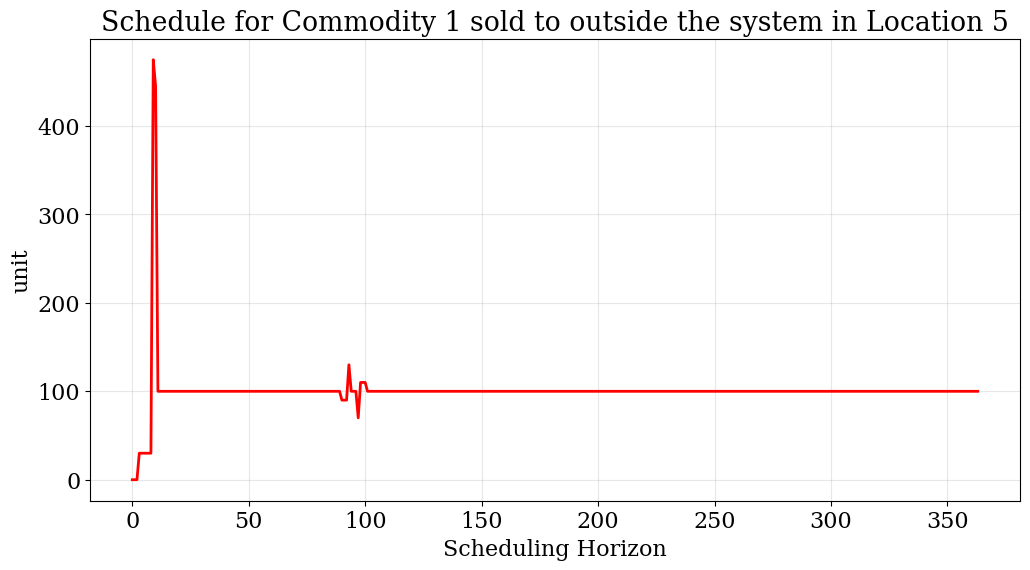

In [40]:
plot_results.schedule(results=ncl_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

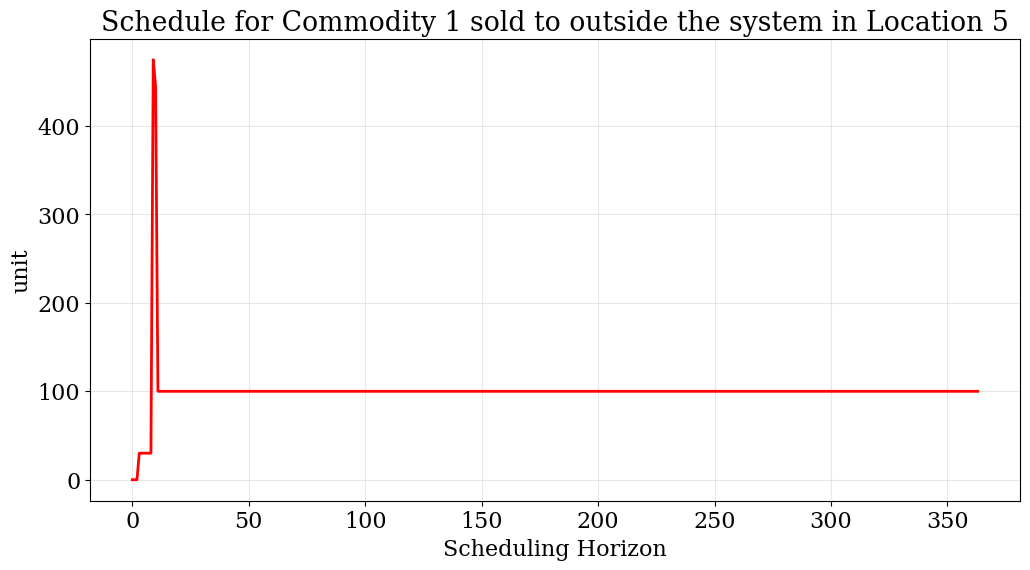

In [41]:
plot_results.schedule(results=cl_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

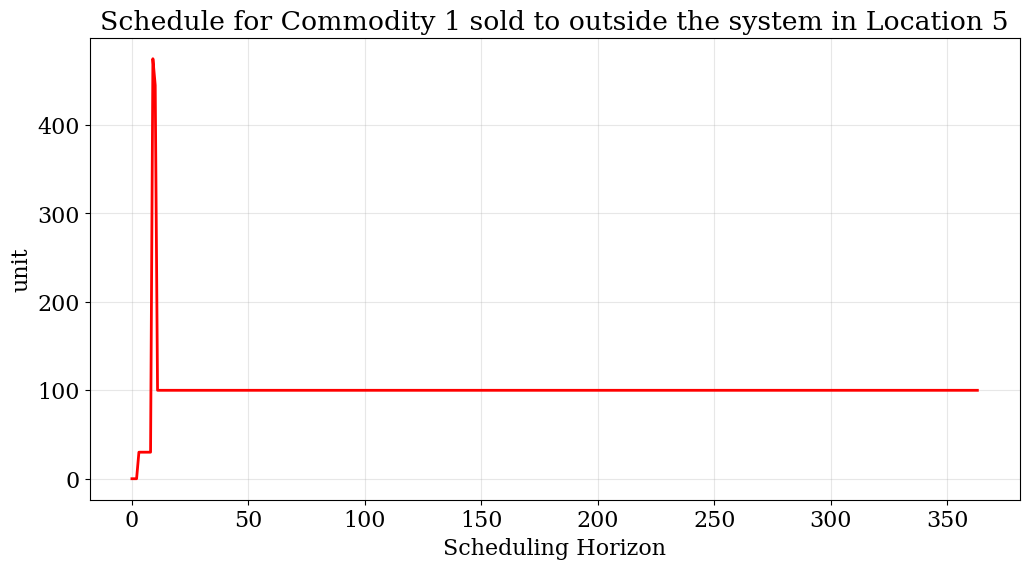

In [21]:
plot_results.schedule(results=cl_step2_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

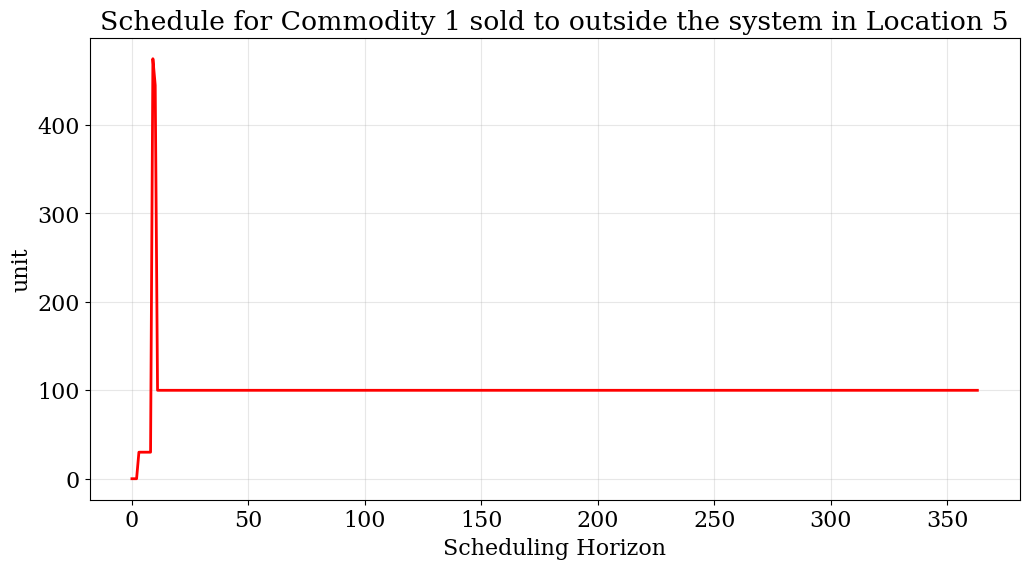

In [22]:
plot_results.schedule(results=cl_step2_ncl_des_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

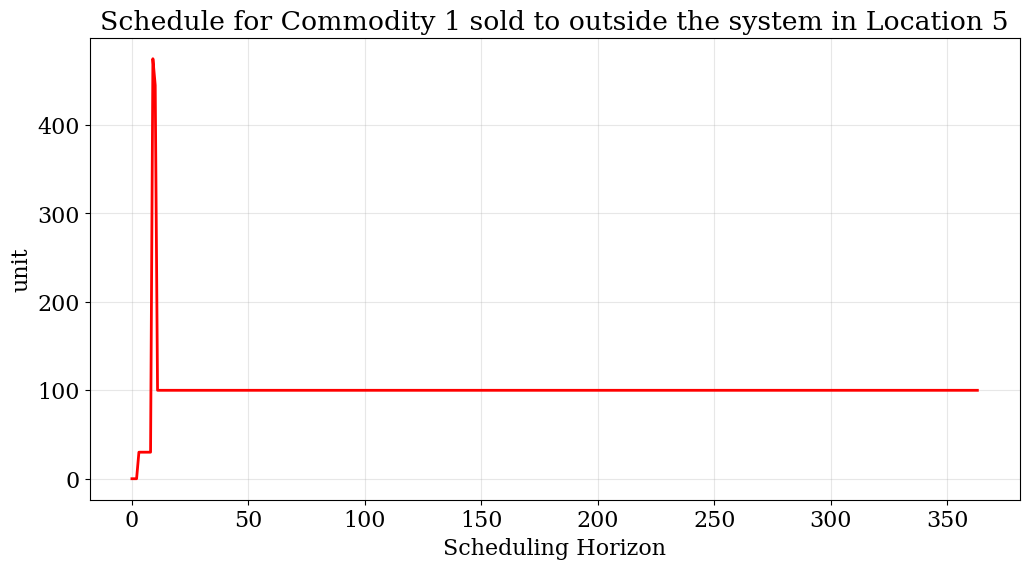

In [38]:
plot_results.schedule(results=cl_step2_res1_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

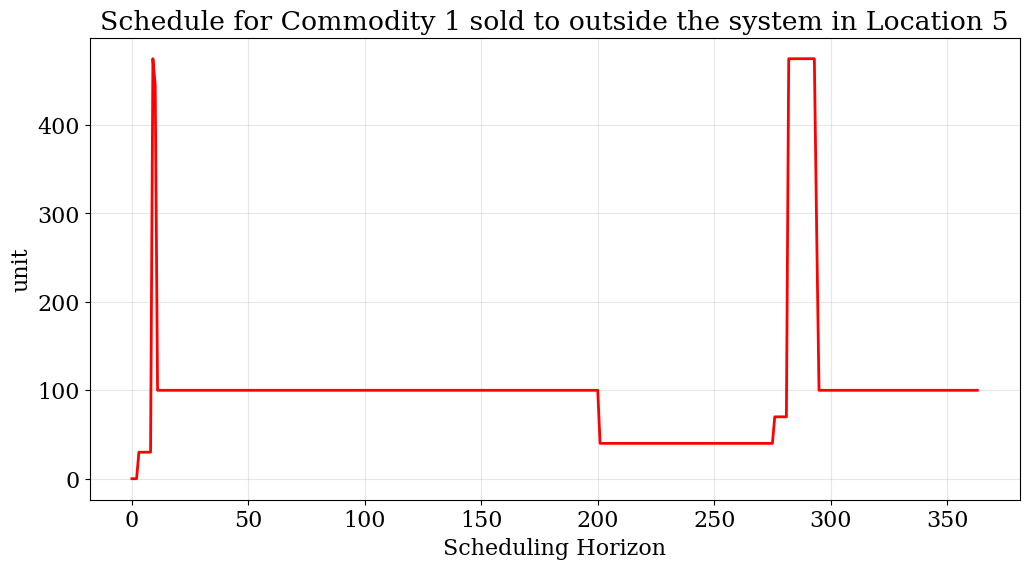

In [56]:
plot_results.schedule(results=cl_step2_res1_ncl_des_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

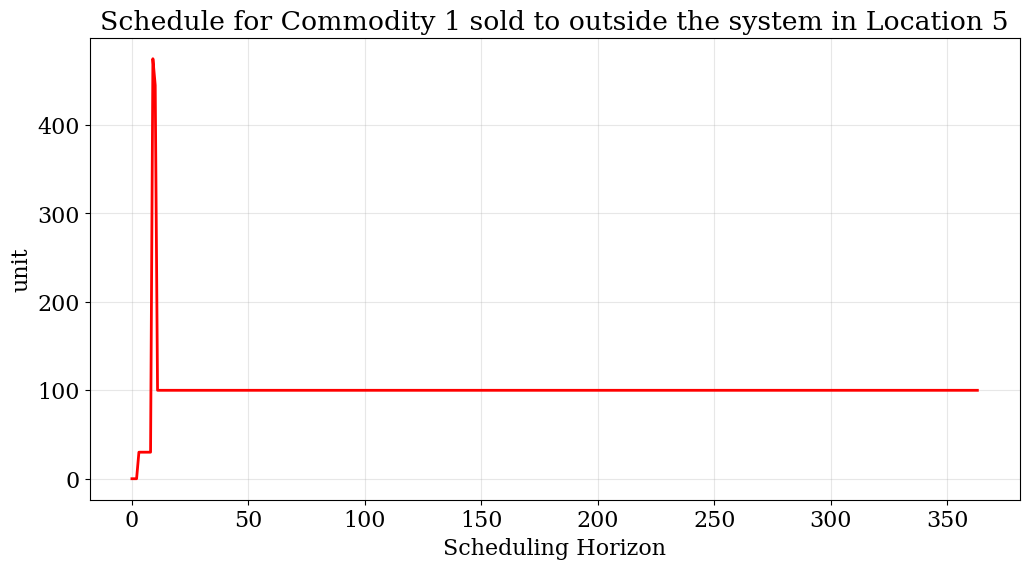

In [23]:
plot_results.schedule(results=cl_step3_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

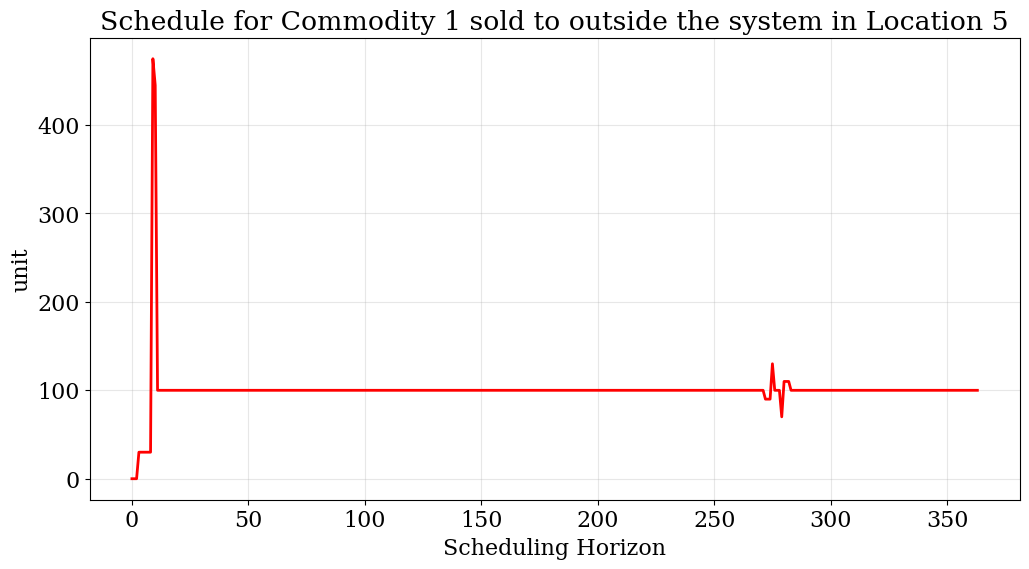

In [24]:
plot_results.schedule(results=cl_step3_ncl_des_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

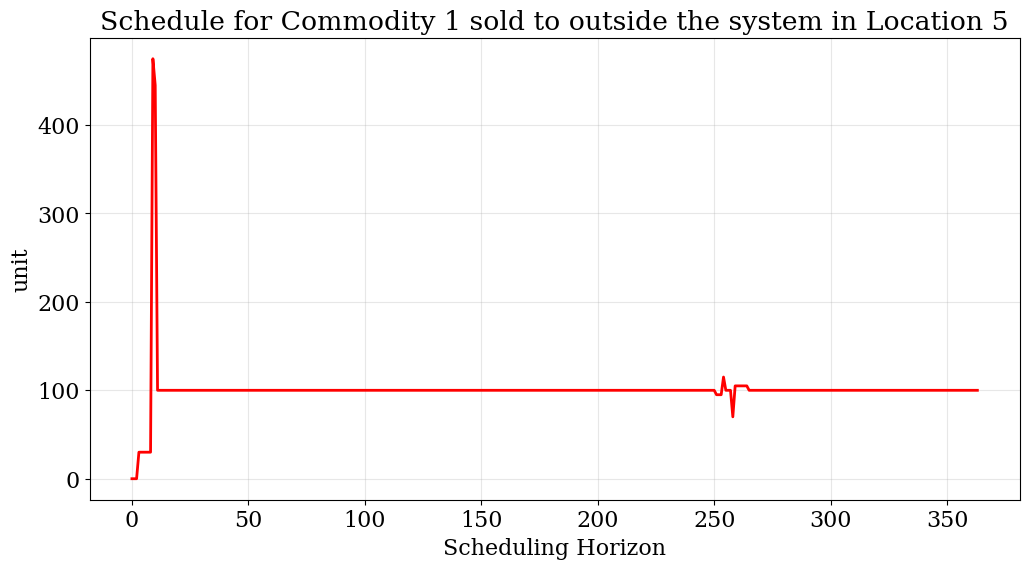

In [25]:
plot_results.schedule(results=cl_step3_sd_ncl_des_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

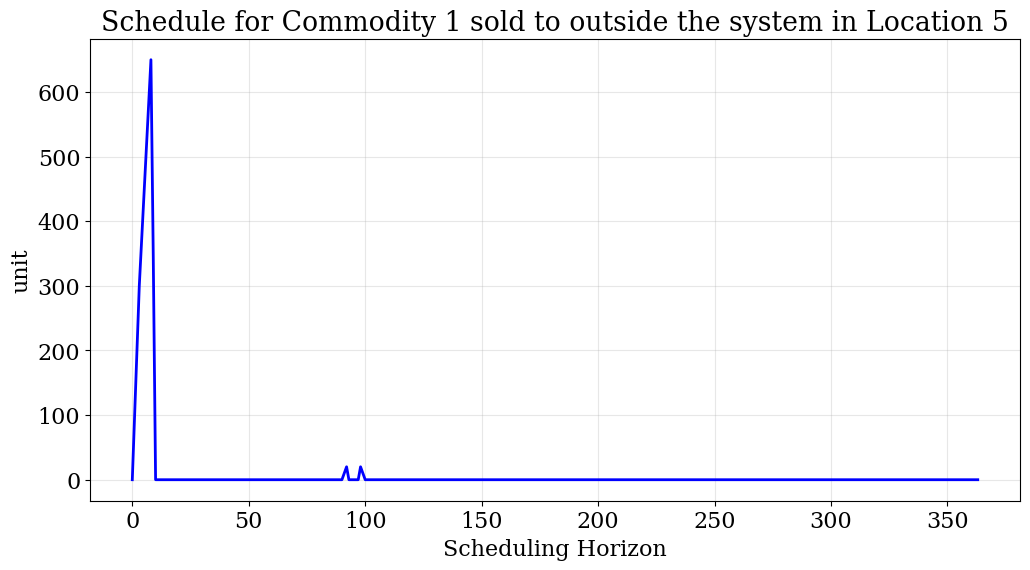

In [42]:
plot_results.schedule(results=ncl_load_results, y_axis='Demand_backlog', component='com1_sold', location='loc5')

In [43]:
b = ncl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + ncl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# a = ncl_load_results.output['objective']
a = cl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + cl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# b = cl_load_results.output['objective']
(b-a)/b

0.031746031746031744

In [44]:
b = cl_step3_sd_ncl_des_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + cl_step3_sd_ncl_des_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
a = cl_step3_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + cl_step3_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
(b-a)/b

NameError: name 'cl_step3_sd_ncl_des_load_results' is not defined

In [45]:
b = cl_step2_res1_ncl_des_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + cl_step2_res1_ncl_des_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# a = ncl_load_results.output['objective']
a = cl_step2_res1_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + cl_step2_res1_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# b = cl_load_results.output['objective']
(b-a)/b

0.9803187713751048

In [29]:
# # a = ph30_ncl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + ph30_ncl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# a = ph30_ncl_load_results.output['objective']
# # b = ph30_cl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + ph30_cl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# b = ph30_cl_load_results.output['objective']
# (b-a)/a

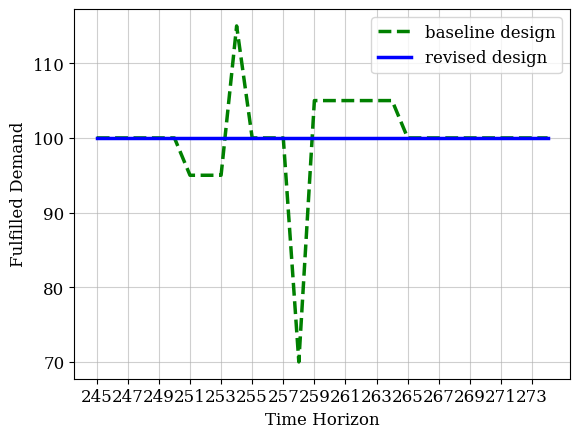

In [32]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=245
end = start+30

ax.plot(range(start, end), list(value for key, value in cl_step3_sd_ncl_des_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='baseline design', color='green', linestyle='--', linewidth='2.5')

ax.plot(range(start, end), list(value for key, value in cl_step3_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='revised design', color='blue', linestyle='-', linewidth='2.5')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
# ax.set_title('FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'cl_ncl_compare', dpi = 300)
# Show the plot
plt.show()

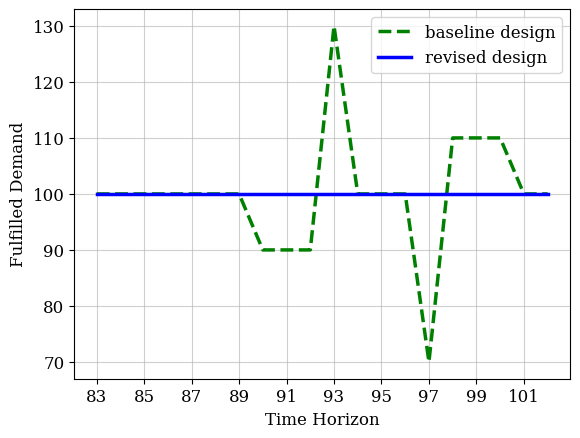

In [46]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=83
end = start+20

ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='baseline design', color='green', linestyle='--', linewidth='2.5')

ax.plot(range(start, end), list(value for key, value in cl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='revised design', color='blue', linestyle='-', linewidth='2.5')

# ax.plot(range(start, end), list(value for key, value in ph30_ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='without learning (ph 30)', color='green', linestyle='--', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in ph30_cl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning (ph 30)', color='green', linestyle='-', linewidth='2.5')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
# ax.set_title('FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'cl_ncl_compare', dpi = 300)
# Show the plot
plt.show()

In [58]:
for k, v in ncl_load_results.output['P'].items():
    if k[0]=='loc5' and k[2]==0 and k[3]==0 and k[4]==0:
        print(k)

('loc5', 'com1_loc1_send', 0, 0, 0)
('loc5', 'com1_loc2_send', 0, 0, 0)
('loc5', 'com1_loc3_send', 0, 0, 0)
('loc5', 'com1_loc4_send', 0, 0, 0)
('loc5', 'com1_loc5_send', 0, 0, 0)
('loc5', 'com1_loc6_send', 0, 0, 0)
('loc5', 'com1_loc7_send', 0, 0, 0)
('loc5', 'com1_process', 0, 0, 0)
('loc5', 'com1_receive_loc1', 0, 0, 0)
('loc5', 'com1_receive_loc2', 0, 0, 0)
('loc5', 'com1_receive_loc3', 0, 0, 0)
('loc5', 'com1_receive_loc4', 0, 0, 0)
('loc5', 'com1_receive_loc5', 0, 0, 0)
('loc5', 'com1_receive_loc6', 0, 0, 0)
('loc5', 'com1_receive_loc7', 0, 0, 0)
('loc5', 'com1_store', 0, 0, 0)
('loc5', 'com1_store_discharge', 0, 0, 0)
('loc5', 'procure com1', 0, 0, 0)
('loc5', 'sell com1', 0, 0, 0)


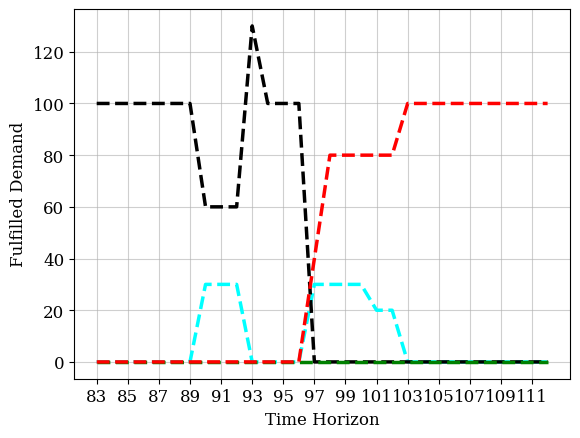

In [70]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=83
end = start+30

focal_results_1 = cl_load_results
focal_results_2 = ncl_load_results

l = 1
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]==f'com1_receive_loc{l}')[start:end], label=f'location {l}', color='cyan', linestyle='-', linewidth='2.5')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]==f'com1_receive_loc{l}')[start:end], color='cyan', linestyle='--', linewidth='2.5')

l = 2
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]==f'com1_receive_loc{l}')[start:end], label=f'location {l}', color='black', linestyle='-', linewidth='2.5')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]==f'com1_receive_loc{l}')[start:end], color='black', linestyle='--', linewidth='2.5')

l = 7
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]==f'com1_receive_loc{l}')[start:end], label=f'location {l}', color='green', linestyle='-', linewidth='2.5')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]==f'com1_receive_loc{l}')[start:end], color='green', linestyle='--', linewidth='2.5')

l = 4
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]==f'com1_receive_loc{l}')[start:end], label=f'location {l}', color='red', linestyle='-', linewidth='2.5')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]==f'com1_receive_loc{l}')[start:end], color='red', linestyle='--', linewidth='2.5')

# ax.plot(range(start, end), list(value for key, value in ph30_ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='without learning (ph 30)', color='green', linestyle='--', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in ph30_cl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning (ph 30)', color='green', linestyle='-', linewidth='2.5')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
# ax.set_title('FIX TITLE')
# ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'cl_ncl_compare', dpi = 300)
# Show the plot
plt.show()

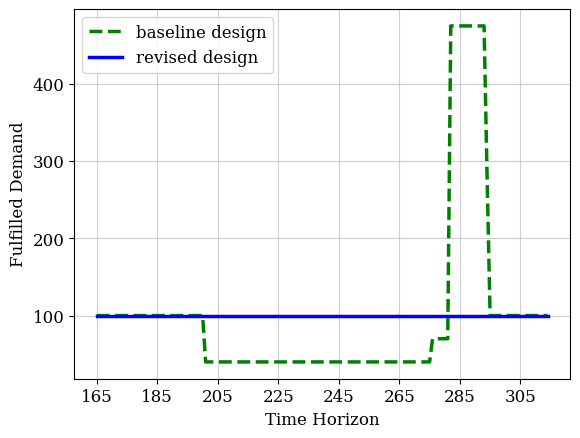

In [79]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=165
end = start+150

ax.plot(range(start, end), list(value for key, value in cl_step2_res1_ncl_des_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='baseline design', color='green', linestyle='--', linewidth='2.5')

ax.plot(range(start, end), list(value for key, value in cl_step2_res1_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='revised design', color='blue', linestyle='-', linewidth='2.5')

# ax.plot(range(start, end), list(value for key, value in ph30_ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='without learning (ph 30)', color='green', linestyle='--', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in ph30_cl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning (ph 30)', color='green', linestyle='-', linewidth='2.5')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
# ax.set_title('FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
# ax.set_yticks(range(0, 100, 20))
ax.set_xticks(range(start, end, 20))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'cl_ncl_compare_bs', dpi = 300)
# Show the plot
plt.show()

In [29]:
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
# rc('text', usetex=False)
# fig, ax = plt.subplots()
# 
# # Plot data from the first dataset
# start=88
# end = start+15
# 
# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], color='green', linestyle='--', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning', color='green', linestyle='-', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in ph30_ncl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], color='blue', linestyle='--', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in ph30_cl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning (ph 30)', color='blue', linestyle='-', linewidth='2.5')
# 
# # Customize the plot
# ax.set_xlabel('Time Horizon')
# ax.set_ylabel('Fulfilled Demand')
# ax.set_title('Amount delivered at customer node')
# ax.legend()
# ax.plot(linewidth=0.5)
# ax.set_xticks(range(start, end, 2))
# # plt.grid(alpha=0.6)
# plt.rcdefaults()
# # plt.savefig(fname = 'cl_ncl_compare', dpi = 300)
# # Show the plot
# plt.show()

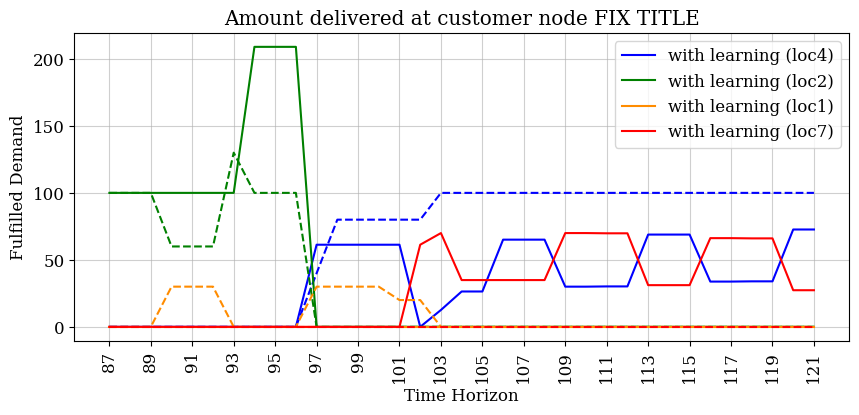

In [30]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=87
end = start+35
focal_results_1 = cl_load_results
focal_results_2 = ncl_load_results

r_cl_loc4 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
r_ncl_loc4 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]

r_cl_loc2 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
r_ncl_loc2 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]

r_cl_loc1 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
r_ncl_loc1 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]

r_cl_loc7 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
r_ncl_loc7 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]

r_cl_dis5 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
r_ncl_dis5 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]

# r_cl_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_loc1, r_cl_loc7, r_cl_dis5, r_cl_loc4, r_cl_loc2)]

ax.plot(range(start, end), r_cl_loc4, label='with learning (loc4)', color='blue', linestyle='-')
ax.plot(range(start, end), r_ncl_loc4, color='blue', linestyle='--')

ax.plot(range(start, end), r_cl_loc2, label='with learning (loc2)', color='green', linestyle='-')
ax.plot(range(start, end), r_ncl_loc2, color='green', linestyle='--')

ax.plot(range(start, end), r_cl_loc1, label='with learning (loc1)', color='darkorange', linestyle='-')
ax.plot(range(start, end), r_ncl_loc1, color='darkorange', linestyle='--')

ax.plot(range(start, end), r_cl_loc7, label='with learning (loc7)', color='red', linestyle='-')
ax.plot(range(start, end), r_ncl_loc7, color='red', linestyle='--')

# ax.plot(range(start, end), r_cl_dis5, label='with learning (dis5)', color='cyan', linestyle='-')
# ax.plot(range(start, end), r_ncl_dis5, color='cyan', linestyle='--')

# ax.plot(range(start, end), r_cl_tot5, label='with learning (tot5)', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with learning (loc2 process)', color='red', linestyle='-.')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('Amount delivered at customer node FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.xticks(rotation=90)
plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'customer_node_delivery_compare', dpi = 300)
# Show the plot
plt.show()

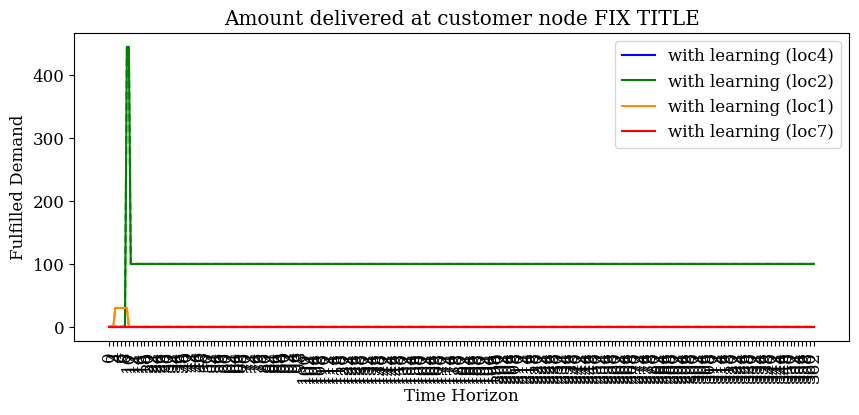

In [31]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=0
end = 363
focal_results_1 = cl_step2_load_results
focal_results_2 = cl_step2_ncl_des_load_results

r_cl_loc4 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
r_ncl_loc4 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]

r_cl_loc2 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
r_ncl_loc2 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]

r_cl_loc1 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
r_ncl_loc1 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]

r_cl_loc7 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
r_ncl_loc7 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]

r_cl_dis5 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
r_ncl_dis5 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]

# r_cl_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_loc1, r_cl_loc7, r_cl_dis5, r_cl_loc4, r_cl_loc2)]

ax.plot(range(start, end), r_cl_loc4, label='with learning (loc4)', color='blue', linestyle='-')
ax.plot(range(start, end), r_ncl_loc4, color='blue', linestyle='--')

ax.plot(range(start, end), r_cl_loc2, label='with learning (loc2)', color='green', linestyle='-')
ax.plot(range(start, end), r_ncl_loc2, color='green', linestyle='--')

ax.plot(range(start, end), r_cl_loc1, label='with learning (loc1)', color='darkorange', linestyle='-')
ax.plot(range(start, end), r_ncl_loc1, color='darkorange', linestyle='--')

ax.plot(range(start, end), r_cl_loc7, label='with learning (loc7)', color='red', linestyle='-')
ax.plot(range(start, end), r_ncl_loc7, color='red', linestyle='--')

# ax.plot(range(start, end), r_cl_dis5, label='with learning (dis5)', color='cyan', linestyle='-')
# ax.plot(range(start, end), r_ncl_dis5, color='cyan', linestyle='--')

# ax.plot(range(start, end), r_cl_tot5, label='with learning (tot5)', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with learning (loc2 process)', color='red', linestyle='-.')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('Amount delivered at customer node FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.xticks(rotation=90)
# plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'customer_node_delivery_compare', dpi = 300)
# Show the plot
plt.show()

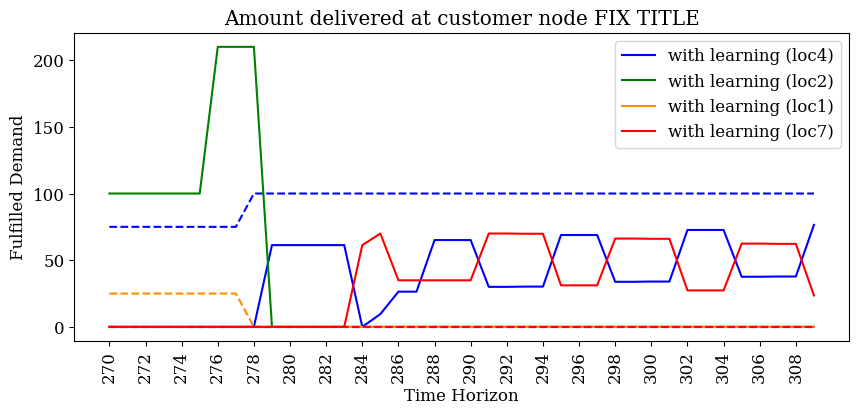

In [33]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=270
end = start + 40
focal_results_1 = cl_step3_load_results
focal_results_2 = cl_step3_sd_ncl_des_load_results

r_cl_loc4 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
r_ncl_loc4 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]

r_cl_loc2 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
r_ncl_loc2 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]

r_cl_loc1 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
r_ncl_loc1 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]

r_cl_loc7 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
r_ncl_loc7 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]

r_cl_dis5 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
r_ncl_dis5 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]

# r_cl_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_loc1, r_cl_loc7, r_cl_dis5, r_cl_loc4, r_cl_loc2)]

ax.plot(range(start, end), r_cl_loc4, label='with learning (loc4)', color='blue', linestyle='-')
ax.plot(range(start, end), r_ncl_loc4, color='blue', linestyle='--')

ax.plot(range(start, end), r_cl_loc2, label='with learning (loc2)', color='green', linestyle='-')
ax.plot(range(start, end), r_ncl_loc2, color='green', linestyle='--')

ax.plot(range(start, end), r_cl_loc1, label='with learning (loc1)', color='darkorange', linestyle='-')
ax.plot(range(start, end), r_ncl_loc1, color='darkorange', linestyle='--')

ax.plot(range(start, end), r_cl_loc7, label='with learning (loc7)', color='red', linestyle='-')
ax.plot(range(start, end), r_ncl_loc7, color='red', linestyle='--')

# ax.plot(range(start, end), r_cl_dis5, label='with learning (dis5)', color='cyan', linestyle='-')
# ax.plot(range(start, end), r_ncl_dis5, color='cyan', linestyle='--')

# ax.plot(range(start, end), r_cl_tot5, label='with learning (tot5)', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with learning (loc2 process)', color='red', linestyle='-.')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('Amount delivered at customer node FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.xticks(rotation=90)
# plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'cl_step2_customer_node_delivery_compare', dpi = 300)
# Show the plot
plt.show()

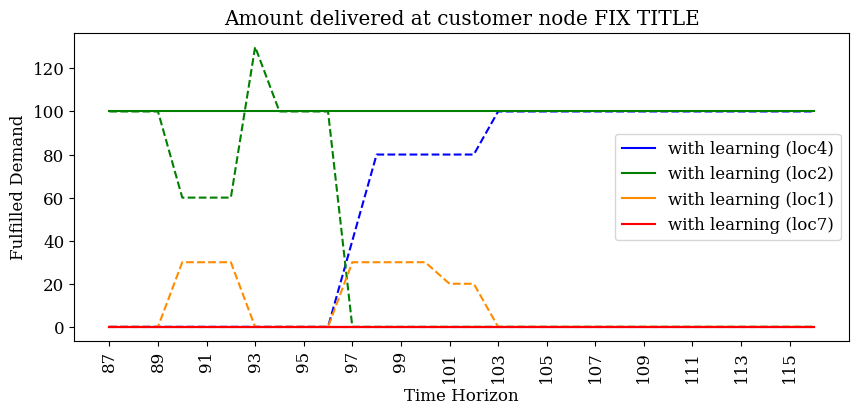

In [33]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=87
end = start+30
focal_results_1 = cl_step2_ncl_des_load_results
focal_results_2 = ncl_load_results

r_cl_loc4 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
r_ncl_loc4 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]

r_cl_loc2 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
r_ncl_loc2 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]

r_cl_loc1 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
r_ncl_loc1 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]

r_cl_loc7 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
r_ncl_loc7 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]

r_cl_dis5 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
r_ncl_dis5 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]

# r_cl_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_loc1, r_cl_loc7, r_cl_dis5, r_cl_loc4, r_cl_loc2)]

ax.plot(range(start, end), r_cl_loc4, label='with learning (loc4)', color='blue', linestyle='-')
ax.plot(range(start, end), r_ncl_loc4, color='blue', linestyle='--')

ax.plot(range(start, end), r_cl_loc2, label='with learning (loc2)', color='green', linestyle='-')
ax.plot(range(start, end), r_ncl_loc2, color='green', linestyle='--')

ax.plot(range(start, end), r_cl_loc1, label='with learning (loc1)', color='darkorange', linestyle='-')
ax.plot(range(start, end), r_ncl_loc1, color='darkorange', linestyle='--')

ax.plot(range(start, end), r_cl_loc7, label='with learning (loc7)', color='red', linestyle='-')
ax.plot(range(start, end), r_ncl_loc7, color='red', linestyle='--')

# ax.plot(range(start, end), r_cl_dis5, label='with learning (dis5)', color='cyan', linestyle='-')
# ax.plot(range(start, end), r_ncl_dis5, color='cyan', linestyle='--')

# ax.plot(range(start, end), r_cl_tot5, label='with learning (tot5)', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with learning (loc2 process)', color='red', linestyle='-.')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('Amount delivered at customer node FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.xticks(rotation=90)
# plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'customer_node_delivery_compare', dpi = 300)
# Show the plot
plt.show()

In [34]:
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
# rc('text', usetex=False)
# fig, ax = plt.subplots(figsize=(10,4))
# 
# # Plot data from the first dataset
# start=87
# end = start+30
# 
# r_cl_step2_loc4 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
# r_cl_loc4 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
# 
# r_cl_step2_loc2 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
# r_cl_loc2 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
# 
# r_cl_step2_loc1 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
# r_cl_loc1 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
# 
# r_cl_step2_loc7 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
# r_cl_loc7 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
# 
# r_cl_step2_dis5 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
# r_cl_dis5 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
# 
# # r_cl_step2_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_step2_loc1, r_cl_step2_loc7, r_cl_step2_dis5, r_cl_step2_loc4, r_cl_step2_loc2)]
# 
# ax.plot(range(start, end), r_cl_step2_loc4, label='with step2 learning (loc4)', color='blue', linestyle='-')
# ax.plot(range(start, end), r_cl_loc4, color='blue', linestyle='--')
# 
# ax.plot(range(start, end), r_cl_step2_loc2, label='with step2 learning (loc2)', color='green', linestyle='-')
# ax.plot(range(start, end), r_cl_loc2, color='green', linestyle='--')
# 
# ax.plot(range(start, end), r_cl_step2_loc1, label='with step2 learning (loc1)', color='darkorange', linestyle='-')
# ax.plot(range(start, end), r_cl_loc1, color='darkorange', linestyle='--')
# 
# ax.plot(range(start, end), r_cl_step2_loc7, label='with step2 learning (loc7)', color='red', linestyle='-')
# ax.plot(range(start, end), r_cl_loc7, color='red', linestyle='--')
# 
# # ax.plot(range(start, end), r_cl_step2_dis5, label='with step2 learning (dis5)', color='cyan', linestyle='-')
# # ax.plot(range(start, end), r_cl_dis5, color='cyan', linestyle='--')
# 
# # ax.plot(range(start, end), r_cl_step2_tot5, label='with step2 learning (tot5)', color='black', linestyle='-')
# 
# # ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# # ax.plot(range(start, end), list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with step2 learning (loc2 process)', color='red', linestyle='-.')
# 
# # Customize the plot
# ax.set_xlabel('Time Horizon')
# ax.set_ylabel('Fulfilled Demand')
# ax.set_title('Amount delivered at customer node FIX TITLE')
# ax.legend()
# ax.plot(linewidth=0.5)
# ax.set_xticks(range(start, end, 2))
# plt.xticks(rotation=90)
# # plt.grid(alpha=0.6)
# plt.rcdefaults()
# plt.savefig(fname = 'customer_node_delivery_compare', dpi = 300)
# # Show the plot
# plt.show()

In [35]:
# x = list(range(len(list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold'))))
# y = list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')
# # y2 = [556280.48, 383540.86, 373214.82, 645751.8, 437765.47]
# # Plotting
# plt.plot(x, y, marker='', label='Location 5')  # 'o' adds circular markers at data points
# # plt.plot(x, y2, marker='x', label='approx_obj')
# plt.title('Delivery under demand variability')
# plt.xlabel('Time Horizon')
# plt.ylabel('Delivery Level')
# plt.grid(True)
# plt.legend()
# plt.savefig(fname = 'MPC_demand', dpi = 300)
# plt.show()

In [36]:
# x = list(range(len(list(value for key, value in ncl_load_results.output['Demand_penalty'].items() if key[0]=='loc5' and key[1]=='com1_sold'))))
# y = list(value for key, value in ncl_load_results.output['Demand_penalty'].items() if key[0]=='loc5' and key[1]=='com1_sold')
# # y2 = [556280.48, 383540.86, 373214.82, 645751.8, 437765.47]
# # Plotting
# plt.plot(x, y, marker='', label='Location 5')  # 'o' adds circular markers at data points
# # plt.plot(x, y2, marker='x', label='approx_obj')
# plt.title('Unmet demand under demand variability')
# plt.xlabel('Time Horizon')
# plt.ylabel('Unmet Demand Level')
# plt.grid(True)
# plt.legend()
# plt.savefig(fname = 'MPC_demand_penalty', dpi = 300)
# plt.show()

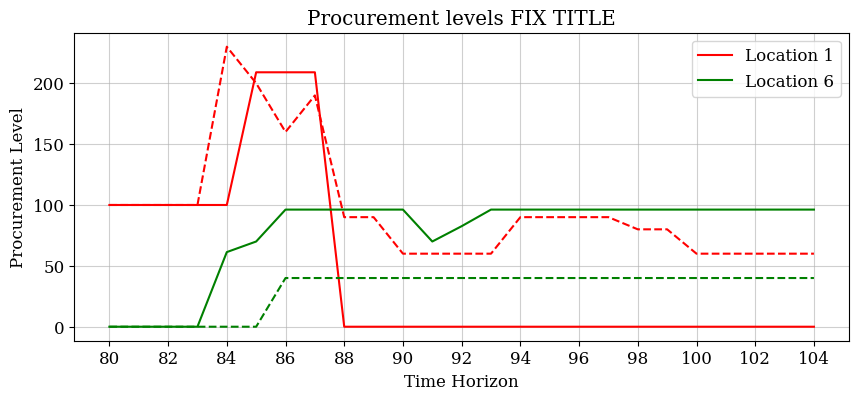

In [37]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=80
end = start+25

focal_results_1 = cl_load_results
focal_results_2 = ncl_load_results

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], label='Location 1', color='red', linestyle='-')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], color='red', linestyle='--')

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], label='Location 6', color='green', linestyle='-')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], color='green', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Procurement Level')
ax.set_title('Procurement levels FIX TITLE')
ax.set_xticks(range(start, end, 2))
ax.legend()
ax.plot(linewidth=0.5)
plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'MPC_procurement_compare', dpi = 300)
# Show the plot
plt.show()

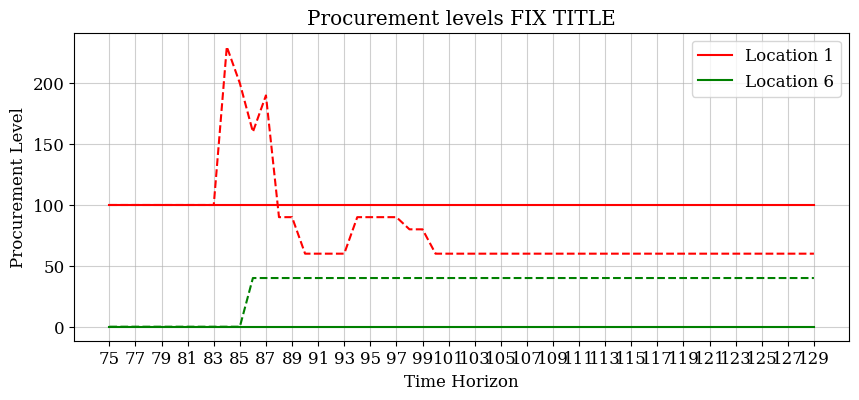

In [38]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=75
end = 130

focal_results_1 = cl_step3_load_results
focal_results_2 = ncl_load_results

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], label='Location 1', color='red', linestyle='-')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], color='red', linestyle='--')

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], label='Location 6', color='green', linestyle='-')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], color='green', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Procurement Level')
ax.set_title('Procurement levels FIX TITLE')
ax.set_xticks(range(start, end, 2))
ax.legend()
ax.plot(linewidth=0.5)
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_procurement_compare', dpi = 300)
# Show the plot
plt.show()

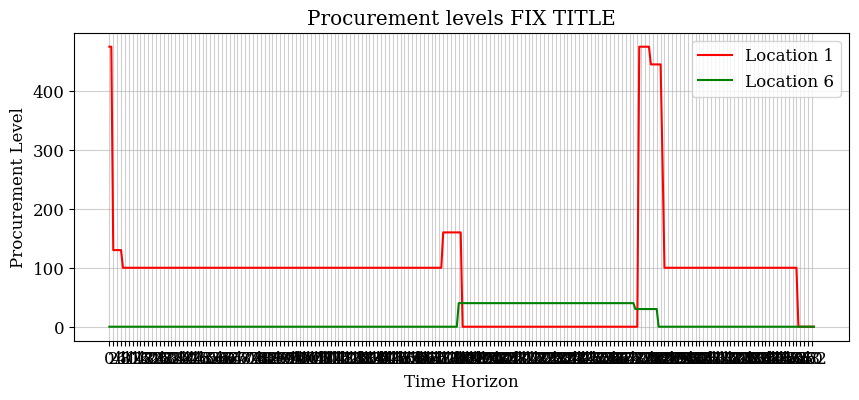

In [57]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=0
end = 364

focal_results_1 = cl_step2_res1_ncl_des_load_results
# focal_results_2 = ncl_load_results

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], label='Location 1', color='red', linestyle='-')
# ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], color='red', linestyle='--')

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], label='Location 6', color='green', linestyle='-')
# ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], color='green', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Procurement Level')
ax.set_title('Procurement levels FIX TITLE')
ax.set_xticks(range(start, end, 2))
ax.legend()
ax.plot(linewidth=0.5)
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_procurement_compare', dpi = 300)
# Show the plot
plt.show()

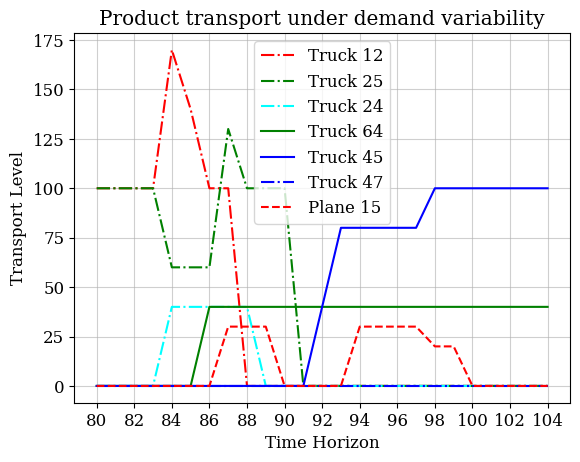

In [51]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=80
end = start+25

focal_results_1 = ncl_load_results

a=1
b=2
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='-.')

a=2
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-.')

a=2
b=4
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='cyan', linestyle='-.')

a=6
b=4
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-')

a=4
b=7
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-.')

a=1
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Plane {a}{b}', color='red', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

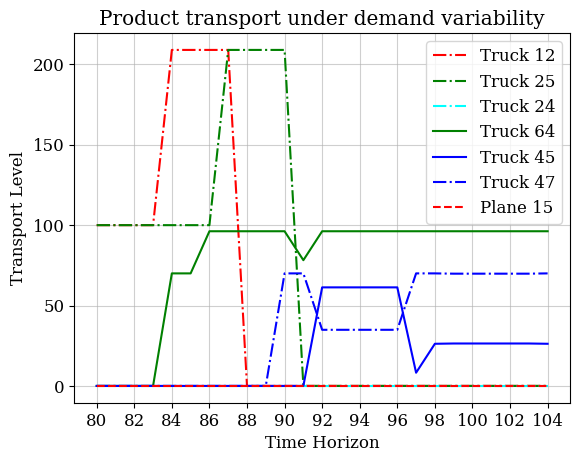

In [52]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=80
end = start+25

focal_results_1 = cl_load_results

a=1
b=2
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='-.')

a=2
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-.')

a=2
b=4
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='cyan', linestyle='-.')

a=6
b=4
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-')

a=4
b=7
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-.')

a=1
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Plane {a}{b}', color='red', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

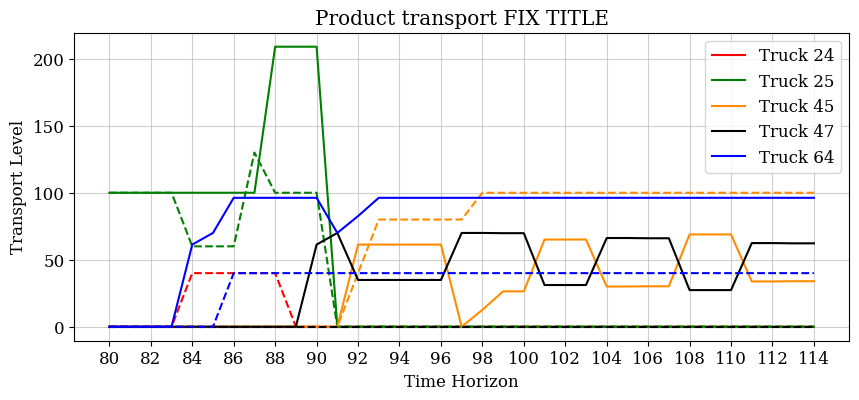

In [40]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=80
end = start+35

focal_results_1 = ncl_load_results
focal_results_2 = cl_load_results

a=2
b=4
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='-')

a=2
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='yellow', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='darkorange', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='darkorange', linestyle='-')

a=4
b=7
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='-')

a=6
b=4
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='blue', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-')

# a=3
# b=4
# # ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='brown', linestyle='--')
# ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='brown', linestyle='-')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport FIX TITLE')
ax.legend(loc='upper right')
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'MPC_logistics_compare', dpi = 300)
# Show the plot
plt.show()

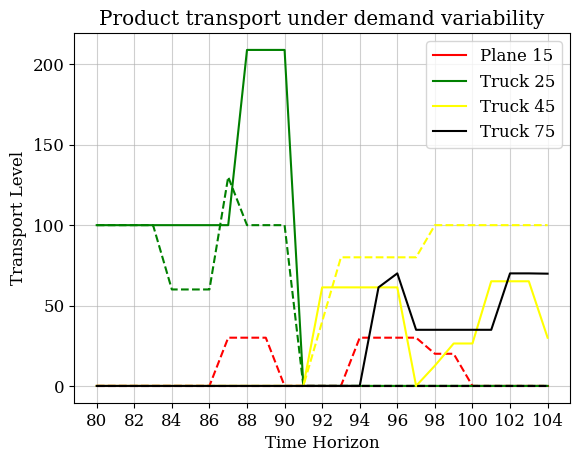

In [41]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=80
end = start+25

focal_results_1 = ncl_load_results
focal_results_2 = cl_load_results

a=1
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Plane {a}{b}', color='red', linestyle='-')

a=2
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='yellow', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='yellow', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='yellow', linestyle='-')

a=7
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end], label='Loc 5 discharge', color='cyan', linestyle='-')
# ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_process')[start:end], label='Loc 5 process', color='cyan', linestyle='-')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

In [42]:
ncl_load_results.output.keys()

dict_keys(['termination', 'LB', 'UB', 'n_cons', 'n_vars', 'n_binvars', 'n_intvars', 'n_convars', 'n_nonzero', 'P', 'B', 'C', 'S', 'R', 'Inv', 'P_m', 'P_material_m', 'Cap_P', 'Cap_S', 'P_location', 'P_location_material_m', 'S_location', 'R_location', 'C_location', 'B_location', 'P_network', 'S_network', 'R_network', 'C_network', 'B_network', 'Trans_cost_network', 'Fopex_process', 'Vopex_process', 'Capex_process', 'Incidental_process', 'Capex_storage', 'Fopex_location', 'Vopex_location', 'Capex_location', 'Incidental_location', 'Fopex_network', 'Vopex_network', 'Capex_network', 'Incidental_network', 'Inv_network', 'Cost', 'Inv_cost', 'Inv_cost_location', 'Inv_cost_network', 'X_F', 'Cap_F', 'Exp_R', 'Exp_F', 'Exp_F_network', 'Exp', 'Capex_transport', 'Vopex_transport', 'Fopex_transport', 'Capex_transport_network', 'Vopex_transport_network', 'Fopex_transport_network', 'X_P', 'X_S', 'Demand_penalty', 'Demand_penalty_location', 'Demand_penalty_network', 'Demand_penalty_cost', 'Demand_penalty

In [43]:
ncl_load_results.output['objective']

835327.3999999999

In [44]:
cl_load_results.output['objective']

856371.6058953165

In [45]:
cl_step2_ncl_des_load_results.output['objective']

546195.6

In [46]:
cl_step2_load_results.output['objective']

612270.0921349862

In [47]:
cl_step2_load_results.output['Demand_penalty_network'][('com1_sold', 0)]  + cl_step2_load_results.output['Demand_backlog_cost_network'][('com1_sold', 0)]

175470.0

In [48]:
cl_step2_ncl_des_load_results.output['Demand_penalty_network'][('com1_sold', 0)] + cl_step2_ncl_des_load_results.output['Demand_backlog_cost_network'][('com1_sold', 0)]

175470.0

In [59]:
cl_step2_res1_ncl_des_load_results.output['objective']

11994086.4

In [61]:
cl_step2_res1_ncl_des_load_results.output['Demand_penalty_network'][('com1_sold', 0)] + cl_step2_res1_ncl_des_load_results.output['Demand_backlog_cost_network'][('com1_sold', 0)]

11223150.0

In [49]:
# # --- Input Data -------------------------------------------------------------
# categories = ["Bin CAPEX", "Transport CAPEX", "OPEX", "Transport OPEX", "Backlog Penalty"]
# 
# # Replace these with your actual values
# scenario1 = [10, 20, 35, 15, 5]    # e.g., without learning
# scenario2 = [8, 18, 30, 20, 3]     # e.g., with learning
# 
# # Labels for scenarios
# scenario_labels = ["Without Learning", "With Learning"]
# 
# # --- Plotting ---------------------------------------------------------------
# x = np.arange(len(categories))       # positions of categories
# width = 0.35                         # width of each bar
# 
# fig, ax = plt.subplots(figsize=(10, 5))
# 
# # Bars
# bars1 = ax.bar(x - width/2, scenario1, width, label=scenario_labels[0], color='darkblue')
# bars2 = ax.bar(x + width/2, scenario2, width, label=scenario_labels[1], color='darkred')
# 
# # --- Labels & Styling -------------------------------------------------------
# ax.set_ylabel("Cost")
# ax.set_title("Cost Breakdown Comparison Across Scenarios")
# ax.set_xticks(x)
# ax.set_xticklabels(categories, rotation=30, ha='right')
# ax.legend(loc='upper left')
# 
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# 
# plt.show()


In [50]:
cl_step3_load_results.output.keys()

dict_keys(['termination', 'LB', 'UB', 'n_cons', 'n_vars', 'n_binvars', 'n_intvars', 'n_convars', 'n_nonzero', 'P', 'B', 'C', 'S', 'R', 'Inv', 'P_m', 'P_material_m', 'Cap_P', 'Cap_S', 'P_location', 'P_location_material_m', 'S_location', 'R_location', 'C_location', 'B_location', 'P_network', 'S_network', 'R_network', 'C_network', 'B_network', 'Trans_cost_network', 'Fopex_process', 'Vopex_process', 'Capex_process', 'Incidental_process', 'Capex_storage', 'Fopex_location', 'Vopex_location', 'Capex_location', 'Incidental_location', 'Fopex_network', 'Vopex_network', 'Capex_network', 'Incidental_network', 'Inv_network', 'Cost', 'Inv_cost', 'Inv_cost_location', 'Inv_cost_network', 'X_F', 'Cap_F', 'Exp_R', 'Exp_F', 'Exp_F_network', 'Exp', 'Capex_transport', 'Vopex_transport', 'Fopex_transport', 'Capex_transport_network', 'Vopex_transport_network', 'Fopex_transport_network', 'X_P', 'X_S', 'Demand_penalty', 'Demand_penalty_location', 'Demand_penalty_network', 'Demand_penalty_cost', 'Demand_penalty

In [51]:
print(*[(k,v) for k,v in cl_step3_load_results.output['P'].items() if k[0]=='loc2' and k[1] == 'com1_process' and v], sep='\n')

(('loc2', 'com1_process', 0, 0, 3), 445.0)
(('loc2', 'com1_process', 0, 0, 4), 445.0)
(('loc2', 'com1_process', 0, 0, 5), 100.0)
(('loc2', 'com1_process', 0, 0, 6), 100.0)
(('loc2', 'com1_process', 0, 1, 0), 100.0)
(('loc2', 'com1_process', 0, 1, 1), 100.0)
(('loc2', 'com1_process', 0, 1, 2), 100.0)
(('loc2', 'com1_process', 0, 1, 3), 100.0)
(('loc2', 'com1_process', 0, 1, 4), 100.0)
(('loc2', 'com1_process', 0, 1, 5), 100.0)
(('loc2', 'com1_process', 0, 1, 6), 100.0)
(('loc2', 'com1_process', 0, 2, 0), 100.0)
(('loc2', 'com1_process', 0, 2, 1), 100.0)
(('loc2', 'com1_process', 0, 2, 2), 100.0)
(('loc2', 'com1_process', 0, 2, 3), 100.0)
(('loc2', 'com1_process', 0, 2, 4), 100.0)
(('loc2', 'com1_process', 0, 2, 5), 100.0)
(('loc2', 'com1_process', 0, 2, 6), 100.0)
(('loc2', 'com1_process', 0, 3, 0), 100.0)
(('loc2', 'com1_process', 0, 3, 1), 100.0)
(('loc2', 'com1_process', 0, 3, 2), 100.0)
(('loc2', 'com1_process', 0, 3, 3), 100.0)
(('loc2', 'com1_process', 0, 3, 4), 100.0)
(('loc2', '

In [52]:
print(*[(k,v) for k,v in cl_step3_load_results.output['Exp'].items() if k[0]=='loc4' and k[1] == 'loc5' and v], sep='\n')

(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 39, 1), 61.30165289256274)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 39, 2), 61.30165289256274)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 39, 3), 61.30165289256274)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 39, 4), 61.30165289256274)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 39, 5), 61.30165289256274)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 40, 0), 9.586776859498059)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 40, 1), 26.391184573005376)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 40, 2), 26.391184573005376)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 40, 3), 65.08953168044263)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 40, 4), 65.08953168044263)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 40, 5), 65.08953168044263)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 40, 6), 30.0)
(('loc4', 'loc5', 'truck45', 'com1_loc4_out', 0, 41, 0), 30.0)
(('loc4', 'loc5', 'truck45', 'com1_l

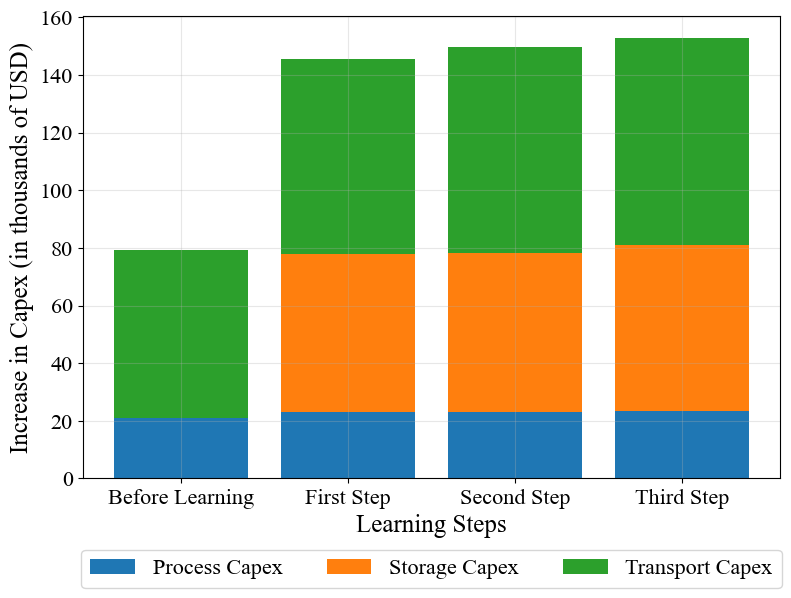

In [19]:
# Your data
ncl_capex_storage = sum(v for k,v in ncl_load_results.output['Capex_storage'].items())/1000
cl_capex_storage = sum(v for k,v in cl_load_results.output['Capex_storage'].items())/1000
cl_step2_capex_storage = sum(v for k,v in cl_step2_load_results.output['Capex_storage'].items())/1000
cl_step3_capex_storage = sum(v for k,v in cl_step3_load_results.output['Capex_storage'].items())/1000
cl_step4_capex_storage = sum(v for k,v in cl_step4_load_results.output['Capex_storage'].items())/1000

ncl_capex_process = sum(v for k,v in ncl_load_results.output['Capex_network'].items())/1000 - ncl_capex_storage
cl_capex_process = sum(v for k,v in cl_load_results.output['Capex_network'].items())/1000 - cl_capex_storage
cl_step2_capex_process = sum(v for k,v in cl_step2_load_results.output['Capex_network'].items())/1000 - cl_step2_capex_storage
cl_step3_capex_process = sum(v for k,v in cl_step3_load_results.output['Capex_network'].items())/1000 - cl_step3_capex_storage
cl_step4_capex_process = sum(v for k,v in cl_step4_load_results.output['Capex_network'].items())/1000 - cl_step4_capex_storage

ncl_capex_transport = sum(v for k,v in ncl_load_results.output['Capex_transport_network'].items())/1000
cl_capex_transport = sum(v for k,v in cl_load_results.output['Capex_transport_network'].items())/1000
cl_step2_capex_transport = sum(v for k,v in cl_step2_load_results.output['Capex_transport_network'].items())/1000
cl_step3_capex_transport = sum(v for k,v in cl_step3_load_results.output['Capex_transport_network'].items())/1000
cl_step4_capex_transport = sum(v for k,v in cl_step4_load_results.output['Capex_transport_network'].items())/1000

data = [
    [ncl_capex_process, cl_step2_capex_process, cl_step3_capex_process, cl_step4_capex_process], # Process Capex
    [ncl_capex_storage, cl_step2_capex_storage, cl_step3_capex_storage, cl_step4_capex_storage], # Storage Capex
    [ncl_capex_transport, cl_step2_capex_transport, cl_step3_capex_transport, cl_step4_capex_transport]  # Transport Capex
]

# data_increment = [
#     [ncl_capex_process, cl_step2_capex_process-ncl_capex_process, cl_step3_capex_process-cl_step2_capex_process, cl_step4_capex_process-cl_step3_capex_process],
#     [ncl_capex_storage, cl_step2_capex_storage-ncl_capex_storage, cl_step3_capex_storage-cl_step2_capex_storage, cl_step4_capex_storage-cl_step3_capex_storage],
#     [ncl_capex_transport, cl_step2_capex_transport-ncl_capex_transport, cl_step3_capex_transport-cl_step2_capex_transport, cl_step4_capex_transport-cl_step3_capex_transport]
# ]

data_increment = [
    [cl_step2_capex_process-ncl_capex_process, cl_step3_capex_process-cl_step2_capex_process, cl_step4_capex_process-cl_step3_capex_process],
    [cl_step2_capex_storage-ncl_capex_storage, cl_step3_capex_storage-cl_step2_capex_storage, cl_step4_capex_storage-cl_step3_capex_storage],
    [cl_step2_capex_transport-ncl_capex_transport, cl_step3_capex_transport-cl_step2_capex_transport, cl_step4_capex_transport-cl_step3_capex_transport]
]
# Create stacked bar plot
# rc('font', size=16)   # simplified & no rcdefaults()

fig, ax = plt.subplots(figsize=(9, 6))
plt.rcdefaults()
rc('font', **{'family': 'Times New Roman', 'size': 16})
# rc('font', **{'size': 16})
labels = ['Process Capex', 'Storage Capex', 'Transport Capex']

data_arr = np.array(data)
for i in range(len(data_arr)):
    ax.bar(
        np.arange(data_arr.shape[1]),
        data_arr[i],
        bottom=np.sum(data_arr[:i], axis=0),
        label=labels[i]
    )

ax.set_xlabel('Learning Steps', fontsize = 18, fontname = 'Times New Roman')
ax.set_ylabel('Increase in Capex (in thousands of USD)', fontsize = 18, fontname = 'Times New Roman')
# ax.set_title('Capital Expenditure Increment', fontsize = 22, fontname = 'Times New Roman')

xtick_positions = np.arange(data_arr.shape[1])
xtick_labels = ['Before Learning', 'First Step', 'Second Step', 'Third Step']
wrapped_labels = [textwrap.fill(label, width=20) for label in xtick_labels]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(wrapped_labels)

# IMPORTANT: capture legend handle
leg = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3)

plt.grid(zorder=0, alpha=0.3)
plt.setp(ax.get_xticklabels(), fontname='Times New Roman')

fig.savefig(
    'Capex_Cost_Breakdown.png',
    dpi=300,
    bbox_inches='tight',
    bbox_extra_artists=(leg,)
)

plt.show()

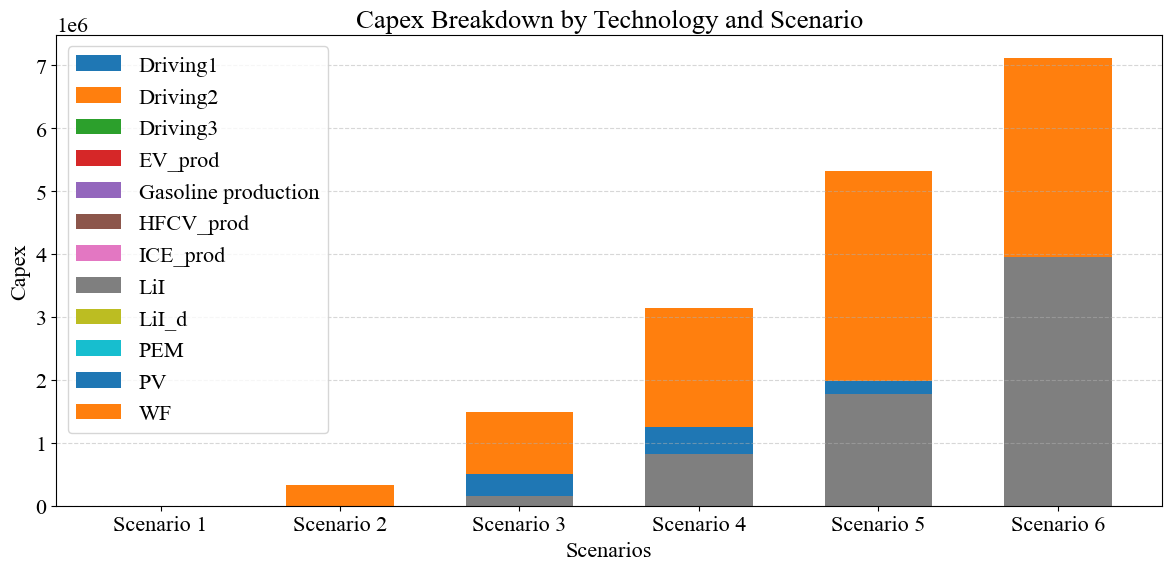

In [55]:
# Initialize technologies and capex data
technologies = [('HO', 'Driving1', 0), ('HO', 'Driving2', 0), ('HO', 'Driving3', 0),
                ('HO', 'EV_prod', 0), ('HO', 'Gasoline production', 0),
                ('HO', 'HFCV_prod', 0), ('HO', 'ICE_prod', 0), ('HO', 'LiI', 0),
                ('HO', 'LiI_d', 0), ('HO', 'PEM', 0), ('HO', 'PV', 0),
                ('HO', 'WF', 0)]

# Capex data (example, replace this with your actual data)
capex_data = [
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 0.0,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 0.0,
     ('HO', 'WF'): 0.0},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 0.0,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 0.0,
     ('HO', 'WF'): 335842.5566191988},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 162203.35236218787,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 341488.63966309716,
     ('HO', 'WF'): 977833.8151999465},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 814381.8026258291,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 439470.26834187517,
     ('HO', 'WF'): 1882113.1042218911},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 1770789.0394942726,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 207876.77348638972,
     ('HO', 'WF'): 3333712.8110114653},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 3951409.887033983,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 0.0,
     ('HO', 'WF'): 3166282.786141873}
]

# Initialize a dictionary to store Capex values for each technology per scenario
capex_by_tech = {tech[1]: [0] * 6 for tech in technologies}  # tech[1] is the technology name (e.g., 'Driving1')

# Extract Capex values for each technology per scenario
for i in range(6):  # Loop over each scenario
    for tech in technologies:
        tech_name = tech[1]  # Extract technology name (e.g., 'EV_prod')
        
        # Check if tech_name exists in the current scenario's Capex data
        tech_key = ('HO', tech_name)  # Create the key to search in capex_data
        if tech_key in capex_data[i]:
            capex_value = capex_data[i][tech_key]
        else:
            capex_value = 0  # If the technology doesn't have a Capex value in this scenario
        
        capex_by_tech[tech_name][i] = capex_value  # Store Capex value for the technology in the respective scenario

# === Prepare data for plotting ===
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.6
x = range(6)

# Create a stacked bar plot with all technologies, including those with zero values
bottoms = [0] * 6  # Start with all bottoms at zero for stacking
for tech, capex_values in capex_by_tech.items():
    # Only plot technologies with non-zero values
    ax.bar(x, capex_values, label=tech, width=bar_width, bottom=bottoms)
    bottoms = [bottoms[i] + capex_values[i] for i in x]  # Update bottoms for stacking

ax.set_xlabel("Scenarios")
ax.set_ylabel("Capex")
ax.set_title("Capex Breakdown by Technology and Scenario")
ax.set_xticks(x)
ax.set_xticklabels([f"Scenario {i+1}" for i in x])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

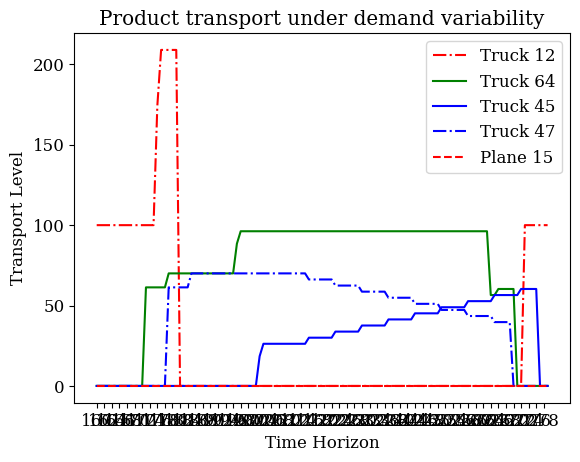

In [51]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=160
end = start+120

focal_results_1 = cl_step2_res1_load_results

a=1
b=2
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='-.')

a=6
b=4
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-')

a=4
b=7
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-.')

a=1
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Plane {a}{b}', color='red', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
# plt.grid(alpha=0.6)
plt.rcdefaults()    
# plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

NameError: name 'cl_step2_res1_ncl_des_load_results' is not defined

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

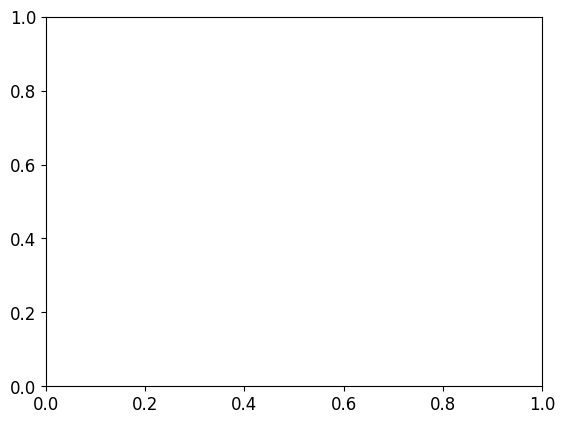

In [11]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=0
end = start+364

focal_results_1 = cl_step2_res1_ncl_des_load_results

a=1
b=2
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='-.')

a=6
b=4
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-')

a=4
b=7
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-.')

a=1
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Plane {a}{b}', color='red', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
# plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

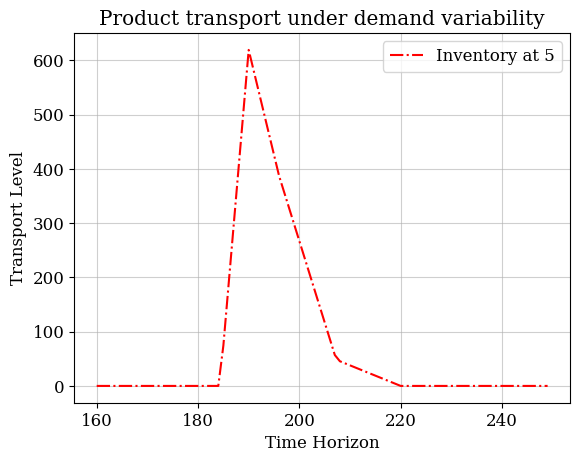

In [10]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=160
end = start+90

focal_results_1 = cl_step2_res1_load_results

a=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Inv'].items() if key[0]==f'loc{a}' and key[1]==f'com1_store_com1_in_stored')[start:end], label=f'Inventory at {a}', color='red', linestyle='-.')

# a=6
# b=4
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')
# 
# a=4
# b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-')
# 
# a=4
# b=7
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-.')
# 
# a=1
# b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Plane {a}{b}', color='red', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 20))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

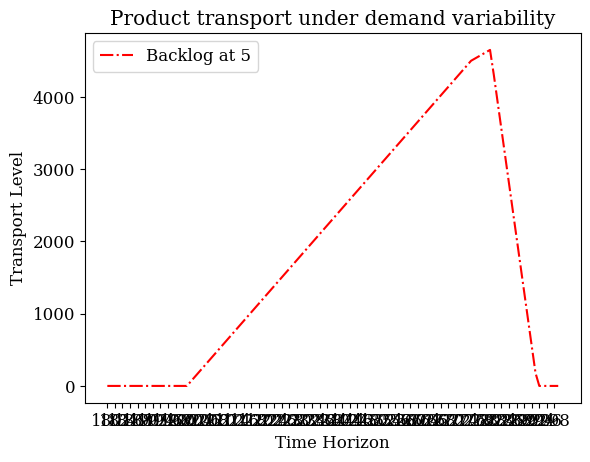

In [69]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=180
end = start+120

focal_results_1 = cl_step2_res1_ncl_des_load_results

a=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Demand_backlog'].items() if key[0]==f'loc{a}' and key[1]==f'com1_sold')[start:end], label=f'Backlog at {a}', color='red', linestyle='-.')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
# plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

In [65]:
cl_step2_res1_ncl_des_load_results.output['Demand_backlog']

{('loc1', 'com1_sold', 0, 0, 0): 0.0,
 ('loc1', 'com1_sold', 0, 0, 1): 0.0,
 ('loc1', 'com1_sold', 0, 0, 2): 0.0,
 ('loc1', 'com1_sold', 0, 0, 3): 0.0,
 ('loc1', 'com1_sold', 0, 0, 4): 0.0,
 ('loc1', 'com1_sold', 0, 0, 5): 0.0,
 ('loc1', 'com1_sold', 0, 0, 6): 0.0,
 ('loc1', 'com1_sold', 0, 1, 0): 0.0,
 ('loc1', 'com1_sold', 0, 1, 1): 0.0,
 ('loc1', 'com1_sold', 0, 1, 2): 0.0,
 ('loc1', 'com1_sold', 0, 1, 3): 0.0,
 ('loc1', 'com1_sold', 0, 1, 4): 0.0,
 ('loc1', 'com1_sold', 0, 1, 5): 0.0,
 ('loc1', 'com1_sold', 0, 1, 6): 0.0,
 ('loc1', 'com1_sold', 0, 2, 0): 0.0,
 ('loc1', 'com1_sold', 0, 2, 1): 0.0,
 ('loc1', 'com1_sold', 0, 2, 2): 0.0,
 ('loc1', 'com1_sold', 0, 2, 3): 0.0,
 ('loc1', 'com1_sold', 0, 2, 4): 0.0,
 ('loc1', 'com1_sold', 0, 2, 5): 0.0,
 ('loc1', 'com1_sold', 0, 2, 6): 0.0,
 ('loc1', 'com1_sold', 0, 3, 0): 0.0,
 ('loc1', 'com1_sold', 0, 3, 1): 0.0,
 ('loc1', 'com1_sold', 0, 3, 2): 0.0,
 ('loc1', 'com1_sold', 0, 3, 3): 0.0,
 ('loc1', 'com1_sold', 0, 3, 4): 0.0,
 ('loc1', 'c